# Cattle Muzzle Individual Dataset Analysis

This notebook provides a comprehensive analysis of the Cattle Muzzle Individual dataset. Cattle muzzle print patterns are unique biometrics (analogous to human fingerprints) that can be used for individual cattle identification. This notebook covers:

- Dataset Importing & Loading (supports both flat directories and pre-split train/val/test layouts).
- Cattle Profiling: Mapping all cattle IDs, counts of images per ID, and identifying the minimum/maximum images per cow.
- Data Visualization: Histogram of the image count distribution and a grid of sample muzzle prints.
- Known/Unknown Separation: Grouping cows based on a threshold of 10 images (cows with < 10 images are unknown, >= 10 are known) and exporting lists to CSVs.
- Duplicate Image Detection: Scanning for exact duplicate files based on MD5 checksums.
- Split Representation Integrity Analysis: Verifying split statistics and integrity.

In [1]:
import os
import hashlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

## 1. Import and Resolve Dataset

In [2]:
def find_dataset_dir():
    search_roots = ["."]
    kaggle_base = "/kaggle/input"
    if os.path.exists(kaggle_base):
        search_roots.append(kaggle_base)
        
    for root_dir in search_roots:
        for root, dirs, files in os.walk(root_dir):
            dirs[:] = [d for d in dirs if d not in ["Known_Cattle", "Unknown_Cattle", "Known_Split"]]
            cattle_dirs = [d for d in dirs if d.startswith("cattle_")]
            if len(cattle_dirs) > 0:
                return root
                
    exact_kaggle_path = "/kaggle/input/datasets/shubhamjha19/cattle/Cattle Muzzle - DB"
    if os.path.exists(exact_kaggle_path) and os.path.isdir(exact_kaggle_path):
        return exact_kaggle_path
        
    for root_dir in search_roots:
        for root, dirs, files in os.walk(root_dir):
            dirs[:] = [d for d in dirs if d not in ["Known_Cattle", "Unknown_Cattle", "Known_Split"]]
            if any(d in dirs for d in ["Cattle Muzzle - DB", "BeefCattle_Muzzle_Individualized"]):
                for d in dirs:
                    if d in ["Cattle Muzzle - DB", "BeefCattle_Muzzle_Individualized"]:
                        return os.path.join(root, d)
            numeric_dirs = [d for d in dirs if d.isdigit()]
            if len(numeric_dirs) > 5:
                return root
                
    raise FileNotFoundError("Could not locate dataset directory.")

def resolve_dataset_dir(path):
    current = path
    while True:
        items = [i for i in os.listdir(current) if not i.startswith('.')]
        if len(items) == 1 and os.path.isdir(os.path.join(current, items[0])):
            current = os.path.join(current, items[0])
        else:
            break
    return current

actual_dataset = resolve_dataset_dir(find_dataset_dir())
eda_folder = "."
print(f"Resolved Dataset Directory: {actual_dataset}")
print(f"EDA Output Folder: {eda_folder}")

Resolved Dataset Directory: /kaggle/input/datasets/shubhamjha19/beefcattle-muzzle-individualized/BeefCattle_Muzzle_Individualized/BeefCattle_Muzzle_Individualized
EDA Output Folder: .


## 2. Scan and Read Dataset

In [3]:
splits = ["train", "val", "test"]
has_splits = all(os.path.exists(os.path.join(actual_dataset, s)) for s in splits)

image_records = []

if has_splits:
    print("Pre-split dataset layout detected.")
    for split in splits:
        split_path = os.path.join(actual_dataset, split)
        cows = sorted([d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d)) and not d.startswith('.')])
        for cow in cows:
            cow_path = os.path.join(split_path, cow)
            files = sorted([f for f in os.listdir(cow_path) if os.path.isfile(os.path.join(cow_path, f)) and not f.startswith('.')])
            for f in files:
                image_records.append({
                    "cattle_id": cow,
                    "filename": f,
                    "filepath": os.path.join(cow_path, f),
                    "original_split": split
                })
else:
    print("Flat dataset layout detected. Performing in-memory split.")
    cows = sorted([d for d in os.listdir(actual_dataset) if os.path.isdir(os.path.join(actual_dataset, d)) and not d.startswith('.')])
    random.seed(42)
    for cow in cows:
        cow_path = os.path.join(actual_dataset, cow)
        files = sorted([f for f in os.listdir(cow_path) if os.path.isfile(os.path.join(cow_path, f)) and not f.startswith('.')])
        shuffled_files = list(files)
        random.shuffle(shuffled_files)
        total_files = len(shuffled_files)
        is_known = total_files >= 10
        if is_known:
            train_size = int(0.70 * total_files)
            val_size = int(0.15 * total_files)
            train_files = shuffled_files[:train_size]
            val_files = shuffled_files[train_size:train_size + val_size]
            test_files = shuffled_files[train_size + val_size:]
            for f in train_files:
                image_records.append({"cattle_id": cow, "filename": f, "filepath": os.path.join(cow_path, f), "original_split": "train"})
            for f in val_files:
                image_records.append({"cattle_id": cow, "filename": f, "filepath": os.path.join(cow_path, f), "original_split": "val"})
            for f in test_files:
                image_records.append({"cattle_id": cow, "filename": f, "filepath": os.path.join(cow_path, f), "original_split": "test"})
        else:
            for f in shuffled_files:
                image_records.append({"cattle_id": cow, "filename": f, "filepath": os.path.join(cow_path, f), "original_split": "test"})

df_images = pd.DataFrame(image_records)
print("Total loaded images:", len(df_images))

df_cows = df_images.groupby("cattle_id").size().reset_index(name="image_count")
df_cows = df_cows.sort_values(by="cattle_id", key=lambda x: x.astype(int) if x.str.isdigit().all() else x)
df_cows.to_csv(os.path.join(eda_folder, "cow_image_counts.csv"), index=False)

print("Total unique cows (cattle IDs):", len(df_cows))
for idx, row in df_cows.iterrows():
    print(f"{row['cattle_id']} : {row['image_count']}")

Flat dataset layout detected. Performing in-memory split.
Total loaded images: 4923
Total unique cows (cattle IDs): 268
cattle_0100 : 8
cattle_0200 : 10
cattle_0300 : 17
cattle_0400 : 7
cattle_0500 : 14
cattle_0600 : 19
cattle_0700 : 16
cattle_0800 : 18
cattle_0900 : 12
cattle_1000 : 12
cattle_1100 : 11
cattle_1200 : 11
cattle_1300 : 12
cattle_1400 : 13
cattle_1500 : 6
cattle_1600 : 14
cattle_1700 : 12
cattle_1800 : 22
cattle_1900 : 8
cattle_2000 : 14
cattle_2100 : 4
cattle_2200 : 6
cattle_2220 : 6
cattle_2300 : 22
cattle_2320 : 14
cattle_2400 : 23
cattle_2500 : 33
cattle_2510 : 10
cattle_2600 : 27
cattle_2700 : 17
cattle_2710 : 15
cattle_2740 : 8
cattle_2800 : 24
cattle_2900 : 15
cattle_2930 : 6
cattle_3000 : 15
cattle_3100 : 13
cattle_3200 : 16
cattle_3300 : 13
cattle_3400 : 7
cattle_3420 : 4
cattle_3802 : 8
cattle_3812 : 12
cattle_3814 : 13
cattle_3819 : 19
cattle_3832 : 42
cattle_3842 : 14
cattle_3844 : 15
cattle_3847 : 21
cattle_3852 : 29
cattle_3856 : 16
cattle_4208 : 18
cattle_4

## 3. Minimum and Maximum Cow Image Counts

In [4]:
min_row = df_cows.loc[df_cows["image_count"].idxmin()]
max_row = df_cows.loc[df_cows["image_count"].idxmax()]

print("Cow ID with Minimum Images:", min_row["cattle_id"])
print("Number of Images:", min_row["image_count"])
print("Cow ID with Maximum Images:", max_row["cattle_id"])
print("Number of Images:", max_row["image_count"])

Cow ID with Minimum Images: cattle_2100
Number of Images: 4
Cow ID with Maximum Images: cattle_4613
Number of Images: 70


## 4. Histogram and Sample Images Grid

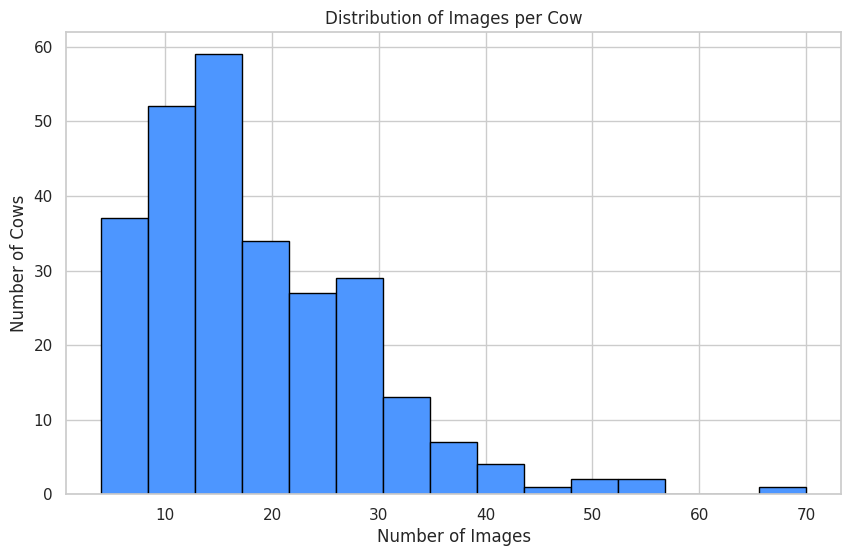

Displaying sample muzzle prints:


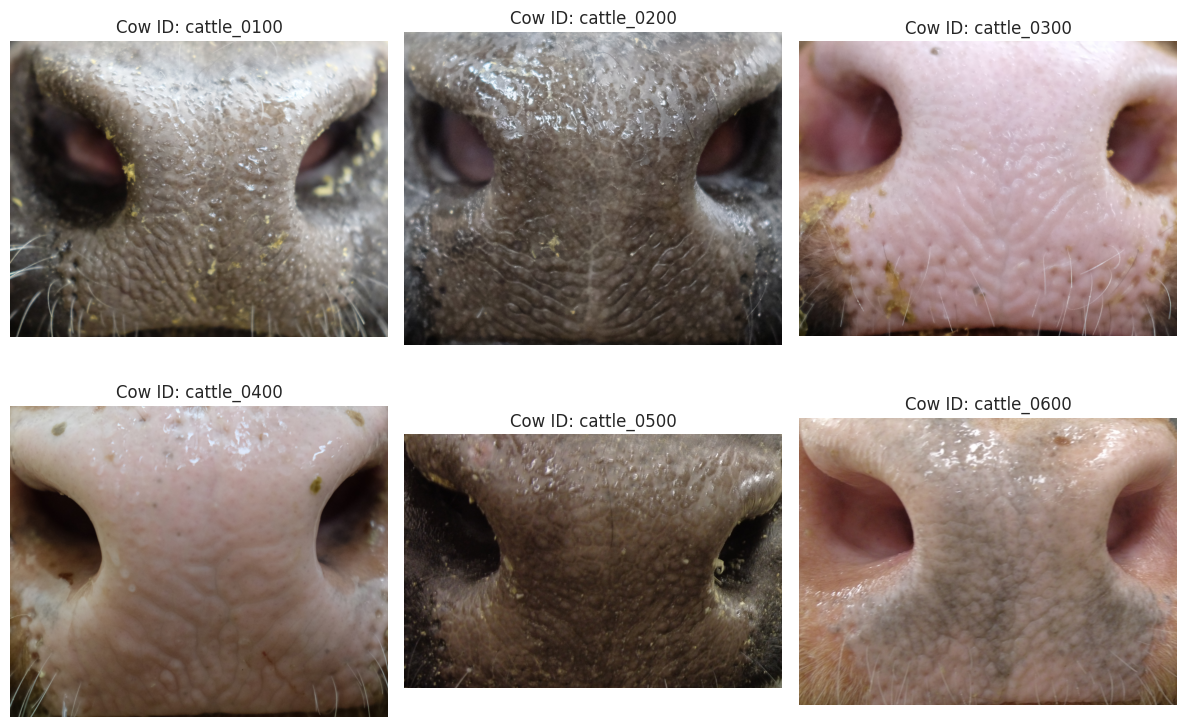

In [5]:
counts = df_cows["image_count"].tolist()
plt.figure(figsize=(10, 6))
plt.hist(counts, color="#4D96FF", edgecolor="black", bins=15)
plt.title("Distribution of Images per Cow")
plt.xlabel("Number of Images")
plt.ylabel("Number of Cows")
plt.savefig(os.path.join(eda_folder, "image_distribution_histogram.png"), dpi=300, bbox_inches="tight")
plt.show()

print("Displaying sample muzzle prints:")
unique_cows = df_cows["cattle_id"].unique()
sample_cows = unique_cows[:6]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for idx, cow in enumerate(sample_cows):
    cow_files = df_images[df_images["cattle_id"] == cow]
    sample_img_path = cow_files.iloc[0]["filepath"]
    img = Image.open(sample_img_path)
    axes[idx].imshow(img)
    axes[idx].set_title(f"Cow ID: {cow}")
    axes[idx].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(eda_folder, "sample_cattle_muzzles.png"), dpi=300, bbox_inches="tight")
plt.show()

## 5. Threshold Separation & Exporting to CSV

In [6]:
threshold = 10
df_cows["status"] = df_cows["image_count"].apply(lambda x: "known" if x >= threshold else "unknown")

known_df = df_cows[df_cows["status"] == "known"]
unknown_df = df_cows[df_cows["status"] == "unknown"]

known_df.to_csv(os.path.join(eda_folder, "known_cows.csv"), index=False)
unknown_df.to_csv(os.path.join(eda_folder, "unknown_cows.csv"), index=False)

print("=" * 60)
print(f"THRESHOLD RESULTS (Threshold = {threshold} images)")
print("=" * 60)
print("Total Known Cattle:  ", len(known_df), "cows")
print("Total Unknown Cattle:", len(unknown_df), "cows")
print("Known Cattle Images:  ", df_images[df_images["cattle_id"].isin(known_df["cattle_id"])].shape[0], "images")
print("Unknown Cattle Images:", df_images[df_images["cattle_id"].isin(unknown_df["cattle_id"])].shape[0], "images")
print("Total Dataset Images: ", len(df_images), "images")
print("=" * 60)

print("\nUnknown Cattle and corresponding image counts:")
if len(unknown_df) > 0:
    for idx, row in unknown_df.iterrows():
        print(f"Cow {row['cattle_id']}: {row['image_count']} images")
else:
    print("No cows have less than 10 images in this dataset configuration.")

print("\nSuccessfully exported 'known_cows.csv' and 'unknown_cows.csv'.")
print("\nRe-importing and printing 'known_cows.csv' preview:")
preview_df = pd.read_csv(os.path.join(eda_folder, "known_cows.csv"))
print(preview_df.head(10))

print("\nRe-importing and printing 'unknown_cows.csv' preview:")
if len(unknown_df) > 0:
    preview_unk = pd.read_csv(os.path.join(eda_folder, "unknown_cows.csv"))
    print(preview_unk.head(10))
else:
    print("unknown_cows.csv is empty (0 unknown cows).")

THRESHOLD RESULTS (Threshold = 10 images)
Total Known Cattle:   227 cows
Total Unknown Cattle: 41 cows
Known Cattle Images:   4656 images
Unknown Cattle Images: 267 images
Total Dataset Images:  4923 images

Unknown Cattle and corresponding image counts:
Cow cattle_0100: 8 images
Cow cattle_0400: 7 images
Cow cattle_1500: 6 images
Cow cattle_1900: 8 images
Cow cattle_2100: 4 images
Cow cattle_2200: 6 images
Cow cattle_2220: 6 images
Cow cattle_2740: 8 images
Cow cattle_2930: 6 images
Cow cattle_3400: 7 images
Cow cattle_3420: 4 images
Cow cattle_3802: 8 images
Cow cattle_4259: 6 images
Cow cattle_4399: 7 images
Cow cattle_4451: 7 images
Cow cattle_4549: 4 images
Cow cattle_4717: 5 images
Cow cattle_4995: 6 images
Cow cattle_5100: 8 images
Cow cattle_5143: 9 images
Cow cattle_5153: 5 images
Cow cattle_5208: 4 images
Cow cattle_5234: 8 images
Cow cattle_5282: 6 images
Cow cattle_5355: 4 images
Cow cattle_5477: 9 images
Cow cattle_5556: 8 images
Cow cattle_5630: 4 images
Cow cattle_5762: 

## 6. Duplicate Image Detection

In [7]:
def check_duplicates(df):
    hashes = {}
    duplicates = []
    for idx, row in df.iterrows():
        with open(row["filepath"], "rb") as f:
            h = hashlib.md5(f.read()).hexdigest()
        if h in hashes:
            duplicates.append((row["filepath"], hashes[h]))
        else:
            hashes[h] = row["filepath"]
    return duplicates

dups = check_duplicates(df_images)
print(f"Total duplicate image files detected: {len(dups)}")
if len(dups) > 0:
    for d in dups:
        print(f"Duplicate: {d[0]} is identical to {d[1]}")

Total duplicate image files detected: 0


## 7. Split Dataset Summary & Exporting Split Mappings

In [8]:
df_split_export = pd.DataFrame({
    "filepath": df_images["filepath"],
    "split": df_images["original_split"]
})
df_split_export.to_csv(os.path.join(eda_folder, "muzzle_dataset_split.csv"), index=False)
print("Successfully exported 'muzzle_dataset_split.csv'.")

train_imgs = df_images[df_images["original_split"] == "train"]
val_imgs = df_images[df_images["original_split"] == "val"]
test_imgs = df_images[df_images["original_split"] == "test"]

print("Train Images :", len(train_imgs))
print("Validation Images :", len(val_imgs))
print("Test Images :", len(test_imgs))
print("Total Split Images :", len(df_images))

total_imgs = len(df_images)
print("Train % :", round(len(train_imgs) / total_imgs * 100, 2))
print("Validation % :", round(len(val_imgs) / total_imgs * 100, 2))
print("Test % :", round(len(test_imgs) / total_imgs * 100, 2))

train_classes = train_imgs["cattle_id"].nunique()
val_classes = val_imgs["cattle_id"].nunique()
test_classes = test_imgs["cattle_id"].nunique()

print("Train Classes:", train_classes)
print("Val Classes:", val_classes)
print("Test Classes:", test_classes)

known_cow_ids = known_df["cattle_id"].tolist()
unknown_cow_ids = unknown_df["cattle_id"].tolist()
known_images_count = df_images[df_images["cattle_id"].isin(known_cow_ids)].shape[0]
unknown_images_count = df_images[df_images["cattle_id"].isin(unknown_cow_ids)].shape[0]

summary_threshold = f"""Threshold: 10

Known Cattle IDs: {len(known_df)}
Unknown Cattle IDs: {len(unknown_df)}

Known Images: {known_images_count}
Unknown Images: {unknown_images_count}

Total Cattle IDs: {len(known_df) + len(unknown_df)}
Total Images: {known_images_count + unknown_images_count}
"""

with open(os.path.join(eda_folder, "threshold_split_summary.txt"), "w") as f:
    f.write(summary_threshold)
print("threshold_split_summary.txt saved successfully.")

train_known_classes = train_imgs[train_imgs["cattle_id"].isin(known_cow_ids)]["cattle_id"].nunique()
val_known_classes = val_imgs[val_imgs["cattle_id"].isin(known_cow_ids)]["cattle_id"].nunique()
test_known_classes = test_imgs[test_imgs["cattle_id"].isin(known_cow_ids)]["cattle_id"].nunique()

summary_split = f"""Known Cattle Split Summary

Known IDs: {len(known_df)}
Known Images: {known_images_count}

Train Classes: {train_known_classes}
Validation Classes: {val_known_classes}
Test Classes: {test_known_classes}

Train Images: {len(train_imgs[train_imgs["cattle_id"].isin(known_cow_ids)])}
Validation Images: {len(val_imgs[val_imgs["cattle_id"].isin(known_cow_ids)])}
Test Images: {len(test_imgs[test_imgs["cattle_id"].isin(known_cow_ids)])}

Train Percentage: {round(len(train_imgs[train_imgs["cattle_id"].isin(known_cow_ids)]) / known_images_count * 100, 2)}%
Validation Percentage: {round(len(val_imgs[val_imgs["cattle_id"].isin(known_cow_ids)]) / known_images_count * 100, 2)}%
Test Percentage: {round(len(test_imgs[test_imgs["cattle_id"].isin(known_cow_ids)]) / known_images_count * 100, 2)}%
"""

with open(os.path.join(eda_folder, "known_split_summary.txt"), "w") as f:
    f.write(summary_split)
print("known_split_summary.txt saved successfully.")


# Open Set Recognition split tuning setup
# Partition unknown cows into validation unknowns and test unknowns
import random
random.seed(42)
shuffled_unknowns = sorted(list(unknown_cow_ids))
random.shuffle(shuffled_unknowns)
split_idx = len(shuffled_unknowns) // 2
val_unknown_ids = shuffled_unknowns[:split_idx]
test_unknown_ids = shuffled_unknowns[split_idx:]

print("============================================================")
print("OSR UNKNOWN SPLIT SUMMARY")
print("============================================================")
print(f"Validation Unknown Cows: {len(val_unknown_ids)}")
print(f"Test Unknown Cows:       {len(test_unknown_ids)}")
print("============================================================")


Successfully exported 'muzzle_dataset_split.csv'.
Train Images : 3164
Validation Images : 582
Test Images : 1177
Total Split Images : 4923
Train % : 64.27
Validation % : 11.82
Test % : 23.91
Train Classes: 227
Val Classes: 227
Test Classes: 268
threshold_split_summary.txt saved successfully.
known_split_summary.txt saved successfully.
OSR UNKNOWN SPLIT SUMMARY
Validation Unknown Cows: 20
Test Unknown Cows:       21


## 8. Split Representation Integrity Analysis

In [9]:
missing_train = []
missing_val = []
missing_test = []

for cow in known_cow_ids:
    if cow not in train_imgs["cattle_id"].values:
        missing_train.append(cow)
    if cow not in val_imgs["cattle_id"].values:
        missing_val.append(cow)
    if cow not in test_imgs["cattle_id"].values:
        missing_test.append(cow)

print("Split Representation Integrity Check:")
print(f"Known cows represented in ALL 3 splits (Train, Val, Test): {len(known_df) - len(set(missing_train + missing_val + missing_test))}")
print(f"Known cows missing from Train: {len(missing_train)}")
print(f"Known cows missing from Validation: {len(missing_val)}")
print(f"Known cows missing from Test: {len(missing_test)}")

Split Representation Integrity Check:
Known cows represented in ALL 3 splits (Train, Val, Test): 227
Known cows missing from Train: 0
Known cows missing from Validation: 0
Known cows missing from Test: 0


## 9. Custom PyTorch Dataset with CLAHE Preprocessing and Augmentation

Here we create a custom PyTorch Dataset class that performs the following steps:
1. Reads each image and converts BGR to RGB space.
2. Converts the RGB image to the YCrCb color space using OpenCV.
3. Applies Contrast Limited Adaptive Histogram Equalization (CLAHE) only to the Y (luminance) channel (Clip Limit: 3.0, Tile Grid Size: (8,8)).
4. Merges the channels and converts back to RGB color space.
5. Applies data augmentation only to the training split.

Created datasets successfully:
- Train Dataset: 3164 samples
- Validation Dataset: 582 samples
- Test Dataset: 910 samples


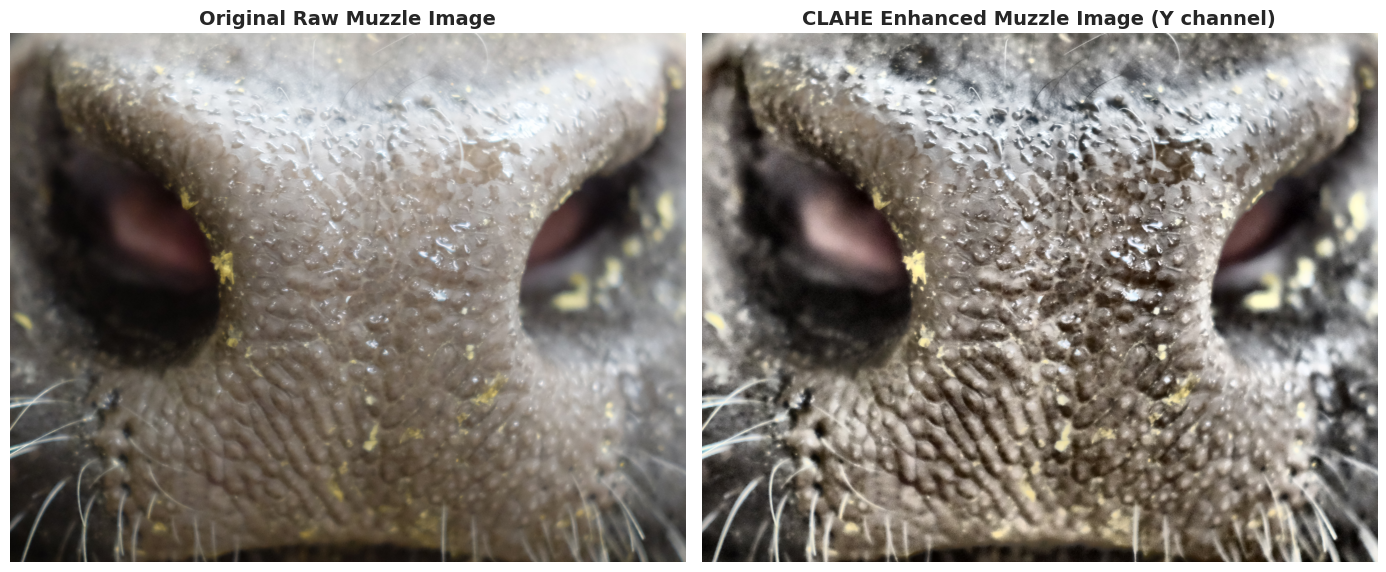

In [10]:
import torch
from torch.utils.data import Dataset
import torchvision.transforms as transforms
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

class CattleMuzzleDataset(Dataset):
    def __init__(self, df_records, transform=None, label_to_idx=None, num_known=None):
        """
        df_records: DataFrame containing 'filepath' and 'cattle_id' columns
        transform: torchvision transforms to apply after CLAHE
        """
        self.filepaths = df_records['filepath'].values
        self.labels = df_records['cattle_id'].values
        self.transform = transform
        
        if label_to_idx is not None:
            self.label_to_idx = label_to_idx
            self.unique_labels = list(label_to_idx.keys())
            self.num_known = num_known
        else:
            # Map cattle_id strings to integer class indices
            self.unique_labels = sorted(list(set(self.labels)))
            self.label_to_idx = {label: idx for idx, label in enumerate(self.unique_labels)}
            self.num_known = len(self.unique_labels)
        
    def __len__(self):
        return len(self.filepaths)
        
    def __getitem__(self, idx):
        filepath = self.filepaths[idx]
        label_name = self.labels[idx]
        if label_name in self.label_to_idx:
            label = self.label_to_idx[label_name]
        else:
            label = self.num_known
        
        # Read image using OpenCV (BGR format)
        img_bgr = cv2.imread(filepath)
        if img_bgr is None:
            img_bgr = np.zeros((224, 224, 3), dtype=np.uint8)
            
        # Convert from BGR to RGB
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        
        # Convert RGB to YCrCb space using OpenCV
        img_ycrcb = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2YCrCb)
        
        # Split channels into Y, Cr, Cb
        y, cr, cb = cv2.split(img_ycrcb)
        
        # Apply Contrast Limited Adaptive Histogram Equalization (CLAHE) only to the Y (luminance) channel
        # Clip Limit: 3.0, Tile Grid Size: (8, 8)
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        y_enhanced = clahe.apply(y)
        
        # Merge channels back
        ycrcb_enhanced = cv2.merge((y_enhanced, cr, cb))
        
        # Convert the image back to the RGB color space
        img_enhanced_rgb = cv2.cvtColor(ycrcb_enhanced, cv2.COLOR_YCrCb2RGB)
        
        # Convert to PIL Image for torchvision transforms
        img_pil = Image.fromarray(img_enhanced_rgb)
        
        # Apply transformations (data augmentation on training, resize/tensor conversion on validation/test)
        if self.transform:
            img_tensor = self.transform(img_pil)
        else:
            default_trans = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor()
            ])
            img_tensor = default_trans(img_pil)
            
        return img_tensor, label

# Define training data augmentation (applied after CLAHE enhancement)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Define validation/test transforms (No data augmentation)
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Instantiate datasets
train_dataset = CattleMuzzleDataset(train_imgs, transform=train_transform)

# Standard validation dataset (known classes only, for training validation loop)
val_dataset = CattleMuzzleDataset(
    val_imgs, 
    transform=val_test_transform, 
    label_to_idx=train_dataset.label_to_idx, 
    num_known=train_dataset.num_known
)

# Standard test dataset (known classes only)
test_dataset = CattleMuzzleDataset(
    test_imgs[test_imgs["cattle_id"].isin(known_cow_ids)], 
    transform=val_test_transform, 
    label_to_idx=train_dataset.label_to_idx, 
    num_known=train_dataset.num_known
)

# OSR validation dataset (known val + validation unknowns)
val_imgs_known = val_imgs
val_imgs_unknown = test_imgs[test_imgs["cattle_id"].isin(val_unknown_ids)]
val_imgs_osr = pd.concat([val_imgs_known, val_imgs_unknown]).reset_index(drop=True)
val_dataset_osr = CattleMuzzleDataset(
    val_imgs_osr, 
    transform=val_test_transform, 
    label_to_idx=train_dataset.label_to_idx, 
    num_known=train_dataset.num_known
)

# OSR test dataset (known test + test unknowns)
test_imgs_known = test_imgs[test_imgs["cattle_id"].isin(known_cow_ids)]
test_imgs_unknown = test_imgs[test_imgs["cattle_id"].isin(test_unknown_ids)]
test_imgs_osr = pd.concat([test_imgs_known, test_imgs_unknown]).reset_index(drop=True)
test_dataset_osr = CattleMuzzleDataset(
    test_imgs_osr, 
    transform=val_test_transform, 
    label_to_idx=train_dataset.label_to_idx, 
    num_known=train_dataset.num_known
)

print(f"Created datasets successfully:")
print(f"- Train Dataset: {len(train_dataset)} samples")
print(f"- Validation Dataset: {len(val_dataset)} samples")
print(f"- Test Dataset: {len(test_dataset)} samples")

# Visual representation of original raw image vs CLAHE enhanced image
sample_record = df_images.iloc[0]
sample_path = sample_record['filepath']

# Load original image (OpenCV BGR -> RGB)
img_bgr = cv2.imread(sample_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Apply CLAHE pipeline
img_ycrcb = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2YCrCb)
y, cr, cb = cv2.split(img_ycrcb)
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
y_enhanced = clahe.apply(y)
ycrcb_enhanced = cv2.merge((y_enhanced, cr, cb))
img_enhanced_rgb = cv2.cvtColor(ycrcb_enhanced, cv2.COLOR_YCrCb2RGB)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(img_rgb)
axes[0].set_title("Original Raw Muzzle Image", fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_enhanced_rgb)
axes[1].set_title("CLAHE Enhanced Muzzle Image (Y channel)", fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('clahe_muzzle_comparison.png', dpi=300)
plt.show()


## 10. Model Definition (EfficientNet-B0 + ArcFace)

In this section, we define the EfficientNet-B0 backbone integrated with an ArcFace classification head. ArcFace (Additive Angular Margin Loss) helps in learning highly discriminative features by maximizing the angular margin between classes.

In [11]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm

class ArcMarginProduct(nn.Module):
    def __init__(self, in_features, out_features, s=30.0, m=0.50, easy_margin=False):
        super(ArcMarginProduct, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.s = s
        self.m = m
        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)
        self.easy_margin = easy_margin
        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th = math.cos(math.pi - m)
        self.mm = math.sin(math.pi - m) * m

    def forward(self, input, label):
        cosine = F.linear(F.normalize(input), F.normalize(self.weight))
        sine = torch.sqrt(1.0 - torch.pow(cosine, 2)).clamp(0, 1)
        phi = cosine * self.cos_m - sine * self.sin_m
        if self.easy_margin:
            phi = torch.where(cosine > 0, phi, cosine)
        else:
            phi = torch.where(cosine > self.th, phi, cosine - self.mm)
        
        one_hot = torch.zeros(cosine.size(), device=input.device)
        one_hot.scatter_(1, label.view(-1, 1).long(), 1)
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        output *= self.s
        return output

class EfficientNetArcFace(nn.Module):
    def __init__(self, num_classes, embedding_dim=512):
        super(EfficientNetArcFace, self).__init__()
        self.backbone = timm.create_model('efficientnet_b0', pretrained=True, num_classes=0)
        self.fc_embed = nn.Linear(1280, embedding_dim)
        self.arcface = ArcMarginProduct(in_features=embedding_dim, out_features=num_classes, s=30.0, m=0.50)

    def forward(self, x, label=None):
        features = self.backbone(x)
        embeddings = self.fc_embed(features)
        if label is not None:
            output = self.arcface(embeddings, label)
            return output, embeddings
        else:
            cosine = F.linear(F.normalize(embeddings), F.normalize(self.arcface.weight))
            return cosine, embeddings


## 11. Model Training and Evaluation (20 Epochs)

We train the model on the custom dataset splits using the PyTorch MPS backend for 20 epochs. We measure and print the total parameters, total training time, total inference time, train/validation curves, confusion matrix, and classification report.

Using device: cuda


Total Parameters: 4,779,644
Starting training...
Epoch 1/20 | Train Loss: 16.4852 Acc: 0.0032 | Val Loss: 0.4955 Acc: 0.8986
=> Saved new best model weights
Epoch 2/20 | Train Loss: 7.7744 Acc: 0.2288 | Val Loss: 0.0984 Acc: 0.9794
=> Saved new best model weights
Epoch 3/20 | Train Loss: 3.1863 Acc: 0.5891 | Val Loss: 0.1111 Acc: 0.9828
=> Saved new best model weights
Epoch 4/20 | Train Loss: 1.2798 Acc: 0.8148 | Val Loss: 0.0408 Acc: 0.9880
=> Saved new best model weights
Epoch 5/20 | Train Loss: 0.6495 Acc: 0.9251 | Val Loss: 0.0939 Acc: 0.9897
=> Saved new best model weights
Epoch 6/20 | Train Loss: 0.3706 Acc: 0.9652 | Val Loss: 0.1083 Acc: 0.9880
Epoch 7/20 | Train Loss: 0.3161 Acc: 0.9731 | Val Loss: 0.2644 Acc: 0.9845
Epoch 8/20 | Train Loss: 0.3209 Acc: 0.9750 | Val Loss: 0.2049 Acc: 0.9863
Epoch 9/20 | Train Loss: 0.2866 Acc: 0.9782 | Val Loss: 0.0429 Acc: 0.9914
=> Saved new best model weights
Epoch 10/20 | Train Loss: 0.1679 Acc: 0.9867 | Val Loss: 0.1645 Acc: 0.9914
Epoch 1

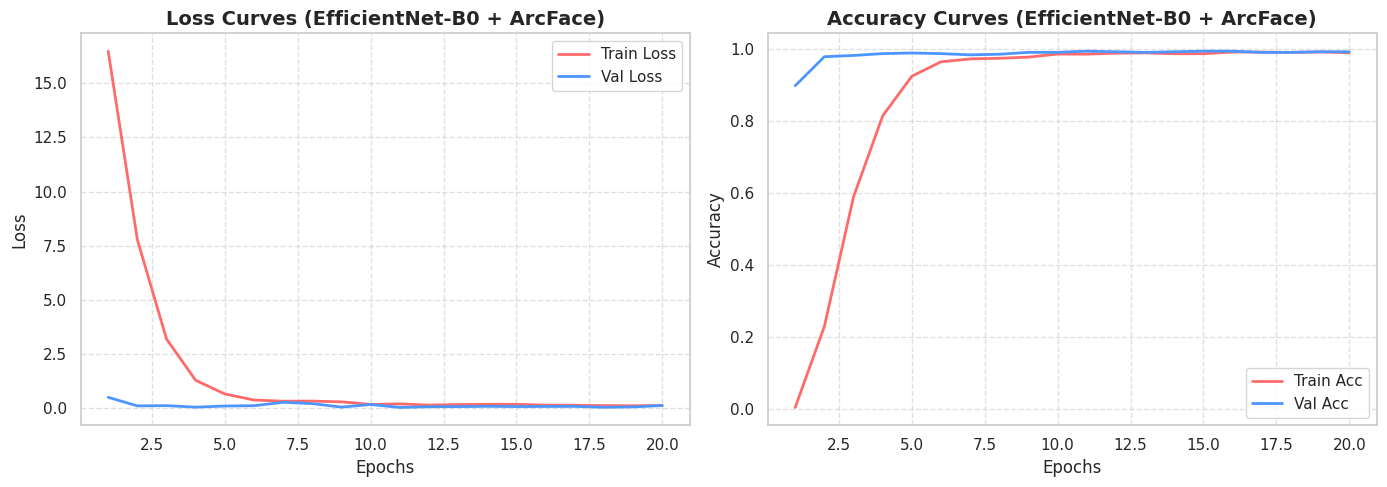

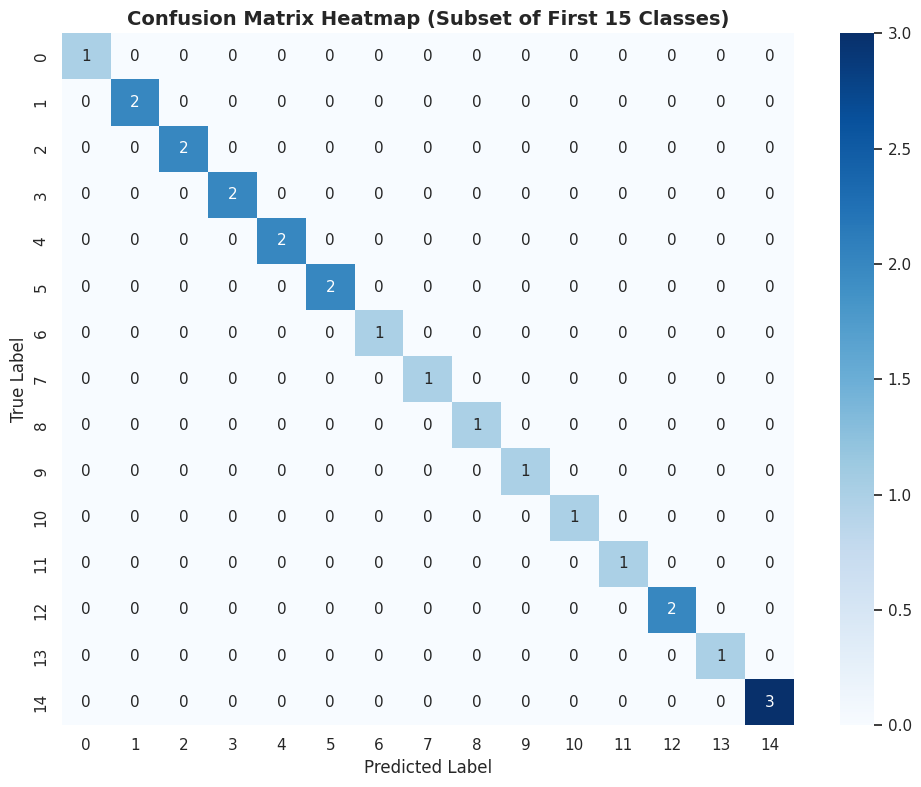

Classification Report:
                 precision    recall  f1-score   support

cow_cattle_0200       1.00      1.00      1.00         1
cow_cattle_0300       1.00      1.00      1.00         2
cow_cattle_0500       1.00      1.00      1.00         2
cow_cattle_0600       1.00      1.00      1.00         2
cow_cattle_0700       1.00      1.00      1.00         2
cow_cattle_0800       1.00      1.00      1.00         2
cow_cattle_0900       1.00      1.00      1.00         1
cow_cattle_1000       1.00      1.00      1.00         1
cow_cattle_1100       1.00      1.00      1.00         1
cow_cattle_1200       1.00      1.00      1.00         1
cow_cattle_1300       1.00      1.00      1.00         1
cow_cattle_1400       1.00      1.00      1.00         1
cow_cattle_1600       1.00      1.00      1.00         2
cow_cattle_1700       1.00      1.00      1.00         1
cow_cattle_1800       1.00      1.00      1.00         3
cow_cattle_2000       1.00      1.00      1.00         2
cow_cat

In [12]:
import time
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

num_classes = len(train_dataset.unique_labels)
model = EfficientNetArcFace(num_classes).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'Total Parameters: {total_params:,}')

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
epochs = 20

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

print('Starting training...')
start_train_time = time.time()

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs, _ = model(images, labels)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = correct / total
    
    model.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs, _ = model(images)
            loss = criterion(outputs * 30.0, labels)
            
            running_val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    epoch_val_loss = running_val_loss / len(val_dataset)
    epoch_val_acc = val_correct / val_total
    
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    
    print(f'Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}')
    
    if 'best_val_acc' not in locals():
        best_val_acc = 0.0
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), 'best_efficientnet_osr.pth')
        print("=> Saved new best model weights")
    
    if 'best_val_acc' not in locals():
        best_val_acc = 0.0
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), 'best_efficientnet_osr.pth')
        print("=> Saved new best model weights")
    
    if 'best_val_acc' not in locals():
        best_val_acc = 0.0
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), 'best_efficientnet_osr.pth')
        print("=> Saved new best model weights")

total_training_time = time.time() - start_train_time
print(f'Total Training Time: {total_training_time:.2f} seconds')

print('Measuring inference time on validation set...')
model.eval()
start_infer_time = time.time()
all_preds = []
all_targets = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs, _ = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(labels.numpy())

total_inference_time = time.time() - start_infer_time
print(f'Total Inference Time (Val Set): {total_inference_time:.4f} seconds')
print(f'Inference Time per Image: {total_inference_time / len(val_dataset):.6f} seconds')

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), history['train_loss'], label='Train Loss', color='#FF6B6B', lw=2)
plt.plot(range(1, epochs + 1), history['val_loss'], label='Val Loss', color='#4D96FF', lw=2)
plt.title('Loss Curves (EfficientNet-B0 + ArcFace)', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), history['train_acc'], label='Train Acc', color='#FF6B6B', lw=2)
plt.plot(range(1, epochs + 1), history['val_acc'], label='Val Acc', color='#4D96FF', lw=2)
plt.title('Accuracy Curves (EfficientNet-B0 + ArcFace)', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.savefig('efficientnet_arcface_curves.png', dpi=300)
plt.show()

cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm[:15, :15], annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Heatmap (Subset of First 15 Classes)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('efficientnet_arcface_confusion_matrix_subset.png', dpi=300)
plt.show()

target_names = [f'cow_{cls}' for cls in train_dataset.unique_labels]
report = classification_report(all_targets, all_preds, target_names=target_names, zero_division=0)
print('Classification Report:')
print(report)


## 12. Open Set Recognition (OSR) Pipeline\n\n
Here we implement the Open Set Recognition pipeline utilizing the 512-dimensional embedding features of our trained model:\n
1. Load the best saved model weights (`best_efficientnet_osr.pth`).\n
2. Extract training embeddings for all known classes and compute their mathematical mean (centroids).\n
3. Apply L2-normalization to the centroids, create a binary dictionary (`prototype_gallery.bin`), and save it.\n
4. Calculate Cosine similarity (dot product of L2-normalized vectors) for the OSR validation set (`val_dataset_osr`), and swipe similarity thresholds from 0.3 to 0.8 to select the optimal threshold maximizing OSR classification accuracy.\n
5. Evaluate on the OSR test set (`test_dataset_osr`) using this optimal threshold, output classification reports, and plot FAR, FRR, EER, and ROC-AUC curves.

Initializing OSR Pipeline...
Successfully saved Prototype Gallery to 'prototype_gallery.bin' with 227 classes.
Optimal Cosine Similarity Threshold tuned on OSR Validation Set: 0.56 (Accuracy: 0.9888)


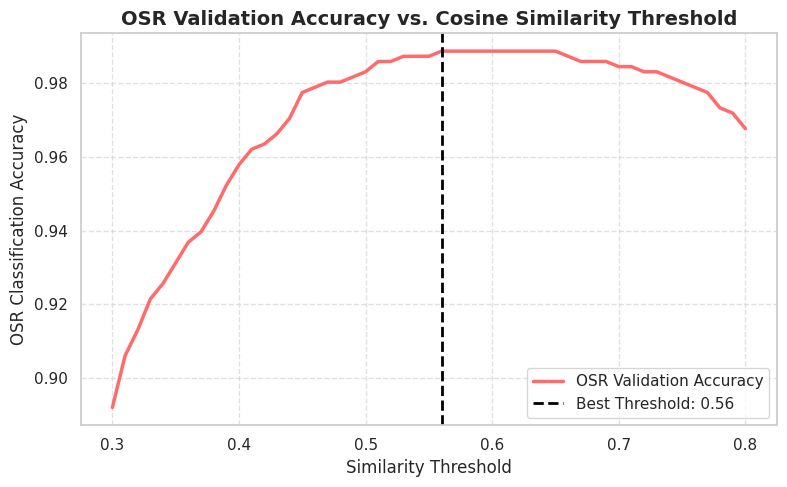

In [13]:
import pickle
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Initializing OSR Pipeline...")
# 1. Load best model weights
model.load_state_dict(torch.load('best_efficientnet_osr.pth', map_location=device))
model.eval()

# 2. Extract training embeddings for all known classes
train_eval_loader = DataLoader(train_dataset, batch_size=16, shuffle=False, num_workers=0)
all_train_embeddings = []
all_train_labels = []

with torch.no_grad():
    for images, labels in train_eval_loader:
        images = images.to(device)
        _, embeddings = model(images)
        all_train_embeddings.append(embeddings.cpu().numpy())
        all_train_labels.extend(labels.numpy())

all_train_embeddings = np.concatenate(all_train_embeddings, axis=0)
all_train_labels = np.array(all_train_labels)

# 3. Build class-wise L2-normalized centroids (Prototype Gallery)
prototype_gallery = {}
idx_to_class = {i: cls for cls, i in train_dataset.label_to_idx.items()}
num_known = train_dataset.num_known

for class_idx in range(num_known):
    class_mask = all_train_labels == class_idx
    class_embeds = all_train_embeddings[class_mask]
    
    # Mathematical mean (centroid)
    centroid = np.mean(class_embeds, axis=0)
    
    # L2 normalization of centroid
    centroid_l2 = centroid / np.linalg.norm(centroid, ord=2)
    
    class_name = idx_to_class[class_idx]
    prototype_gallery[class_name] = centroid_l2

# Save Prototype Gallery as a binary dictionary
gallery_path = "prototype_gallery.bin"
with open(gallery_path, "wb") as f:
    pickle.dump(prototype_gallery, f)
print(f"Successfully saved Prototype Gallery to '{gallery_path}' with {len(prototype_gallery)} classes.")

# 4. Extract OSR validation embeddings
val_eval_loader = DataLoader(val_dataset_osr, batch_size=16, shuffle=False, num_workers=0)
val_embeddings = []
val_targets = []

with torch.no_grad():
    for images, labels in val_eval_loader:
        images = images.to(device)
        _, embeddings = model(images)
        val_embeddings.append(embeddings.cpu().numpy())
        val_targets.extend(labels.numpy())

val_embeddings = np.concatenate(val_embeddings, axis=0)
val_targets = np.array(val_targets)

# Compute max similarity score with the gallery for each validation sample
val_max_similarities = []
val_pred_known_classes = []

gallery_classes = list(prototype_gallery.keys())
gallery_matrix = np.array([prototype_gallery[c] for c in gallery_classes]) # [num_known, 512]

for i in range(len(val_embeddings)):
    # L2 normalize query
    q = val_embeddings[i] / np.linalg.norm(val_embeddings[i], ord=2)
    # Cosine similarity (dot product of L2 normalized vectors)
    sims = np.dot(gallery_matrix, q)
    max_idx = np.argmax(sims)
    val_max_similarities.append(sims[max_idx])
    val_pred_known_classes.append(train_dataset.label_to_idx[gallery_classes[max_idx]])

val_max_similarities = np.array(val_max_similarities)
val_pred_known_classes = np.array(val_pred_known_classes)

# Sweep threshold from 0.3 to 0.8 (in steps of 0.01) to maximize OSR classification accuracy
thresholds = np.arange(0.3, 0.81, 0.01)
best_threshold = 0.5
best_accuracy = 0.0
accuracies = []

for th in thresholds:
    # Match to class if similarity >= th, else flag as unknown (num_known)
    preds = np.where(val_max_similarities >= th, val_pred_known_classes, num_known)
    acc = np.mean(preds == val_targets)
    accuracies.append(acc)
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_threshold = th

print(f"Optimal Cosine Similarity Threshold tuned on OSR Validation Set: {best_threshold:.2f} (Accuracy: {best_accuracy:.4f})")

# Plot threshold vs accuracy curve
plt.figure(figsize=(8, 5))
plt.plot(thresholds, accuracies, color='#FF6B6B', lw=2.5, label='OSR Validation Accuracy')
plt.axvline(best_threshold, color='black', linestyle='--', linewidth=2, label=f'Best Threshold: {best_threshold:.2f}')
plt.title('OSR Validation Accuracy vs. Cosine Similarity Threshold', fontsize=14, fontweight='bold')
plt.xlabel('Similarity Threshold')
plt.ylabel('OSR Classification Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig('val_accuracy_vs_threshold.png', dpi=300)
plt.show()


OSR Test Set Accuracy with threshold 0.56: 0.9579
Saved classification_report_osr_efficientnet.csv

Open Set Recognition Summary Metrics for Unknown Detection:
  - Precision: 0.9519
  - Recall:    0.7279
  - F1-score:  0.8250
Equal Error Rate (EER): 0.0945 at threshold 0.86
OSR Binary Detection AUC: 0.9664


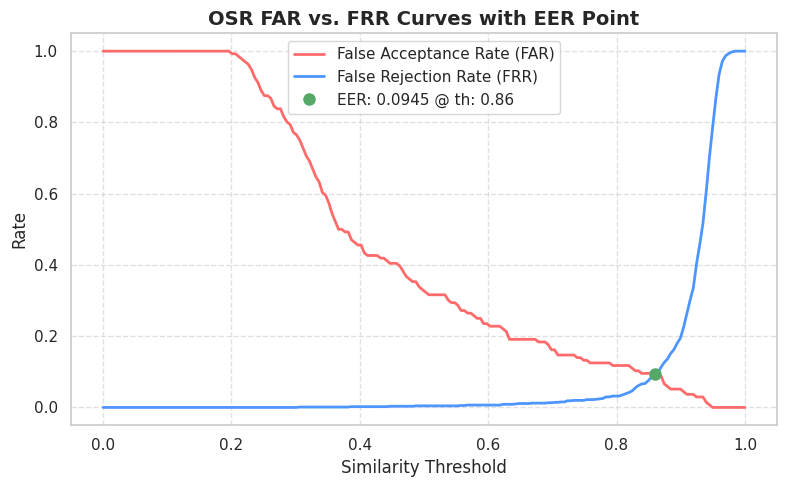

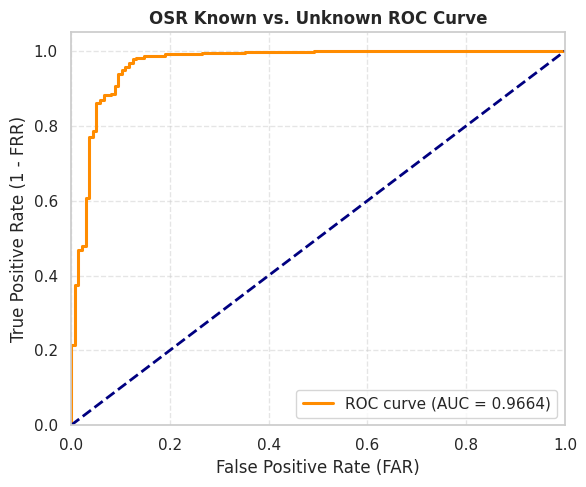

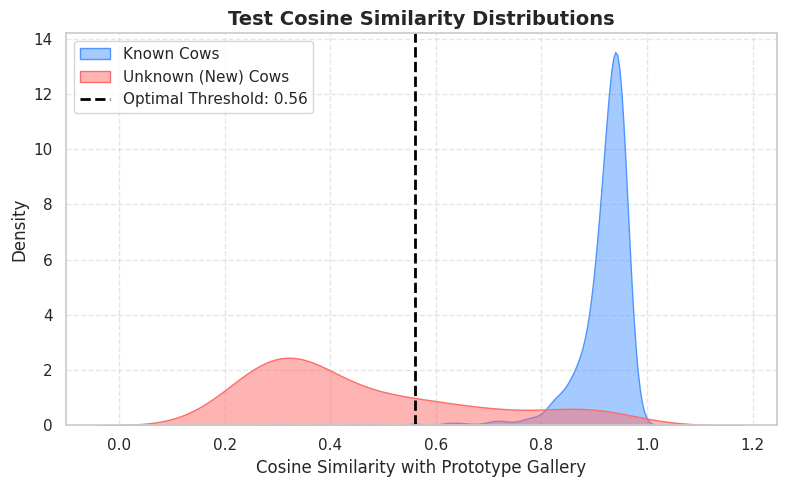

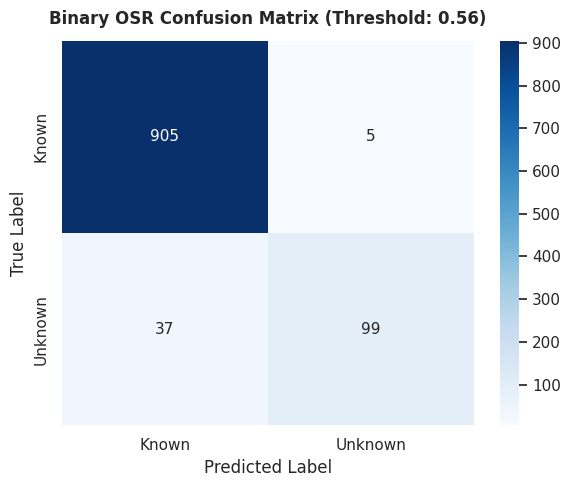

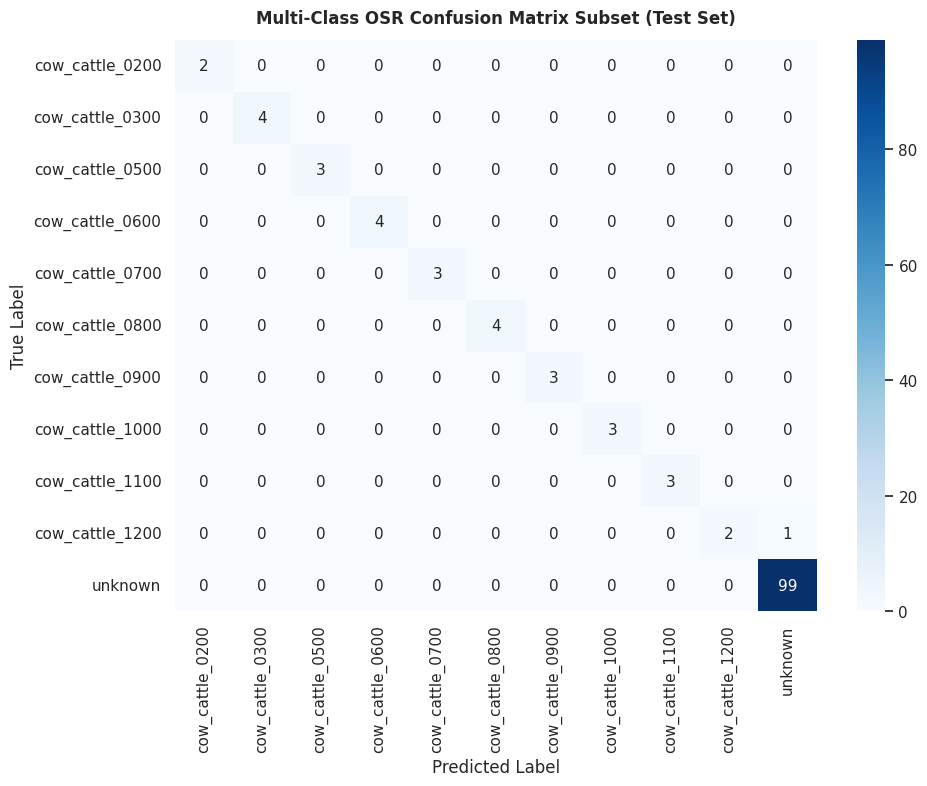

OSR Pipeline complete!


In [14]:
# 5. Extract OSR test embeddings
test_eval_loader = DataLoader(test_dataset_osr, batch_size=16, shuffle=False, num_workers=0)
test_embeddings = []
test_targets = []

with torch.no_grad():
    for images, labels in test_eval_loader:
        images = images.to(device)
        _, embeddings = model(images)
        test_embeddings.append(embeddings.cpu().numpy())
        test_targets.extend(labels.numpy())

test_embeddings = np.concatenate(test_embeddings, axis=0)
test_targets = np.array(test_targets)

# Compute max similarity score with the gallery for each test sample
test_max_similarities = []
test_pred_known_classes = []

for i in range(len(test_embeddings)):
    q = test_embeddings[i] / np.linalg.norm(test_embeddings[i], ord=2)
    sims = np.dot(gallery_matrix, q)
    max_idx = np.argmax(sims)
    test_max_similarities.append(sims[max_idx])
    test_pred_known_classes.append(train_dataset.label_to_idx[gallery_classes[max_idx]])

test_max_similarities = np.array(test_max_similarities)
test_pred_known_classes = np.array(test_pred_known_classes)

# Evaluate using tuned best threshold
test_final_preds = np.where(test_max_similarities >= best_threshold, test_pred_known_classes, num_known)
test_acc = np.mean(test_final_preds == test_targets)
print(f"OSR Test Set Accuracy with threshold {best_threshold:.2f}: {test_acc:.4f}")

# Save OSR classification report
target_names = [f"cow_{cls}" for cls in train_dataset.unique_labels] + ["unknown"]
report_dict = classification_report(
    test_targets,
    test_final_preds,
    labels=list(range(num_known + 1)),
    target_names=target_names,
    output_dict=True,
    zero_division=0
)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv('classification_report_osr_efficientnet.csv', index=True)
print("Saved classification_report_osr_efficientnet.csv")

# Print metrics for Unknown detection
print("\nOpen Set Recognition Summary Metrics for Unknown Detection:")
print(f"  - Precision: {report_dict['unknown']['precision']:.4f}")
print(f"  - Recall:    {report_dict['unknown']['recall']:.4f}")
print(f"  - F1-score:  {report_dict['unknown']['f1-score']:.4f}")

# 6. Calculate FAR and FRR vs threshold
from sklearn.metrics import roc_curve, auc

known_mask = test_targets < num_known
unknown_mask = test_targets == num_known

thresholds_plot = np.linspace(0.0, 1.0, 200)
far_scores = []
frr_scores = []

for th in thresholds_plot:
    # FAR: rate of unknown samples classified as known (max_similarity >= th)
    far = np.mean(test_max_similarities[unknown_mask] >= th) if np.sum(unknown_mask) > 0 else 0.0
    # FRR: rate of known samples classified as unknown (max_similarity < th)
    frr = np.mean(test_max_similarities[known_mask] < th) if np.sum(known_mask) > 0 else 0.0
    far_scores.append(far)
    frr_scores.append(frr)

far_scores = np.array(far_scores)
frr_scores = np.array(frr_scores)

# EER calculation
eer_idx = np.argmin(np.abs(far_scores - frr_scores))
eer = (far_scores[eer_idx] + frr_scores[eer_idx]) / 2.0
eer_threshold = thresholds_plot[eer_idx]
print(f"Equal Error Rate (EER): {eer:.4f} at threshold {eer_threshold:.2f}")

# Binary classification labels for ROC (1 = Known, 0 = Unknown)
binary_labels = np.where(test_targets < num_known, 1, 0)
fpr, tpr, roc_thresholds = roc_curve(binary_labels, test_max_similarities)
roc_auc = auc(fpr, tpr)
print(f"OSR Binary Detection AUC: {roc_auc:.4f}")

# Plot FAR vs FRR curves & show EER
plt.figure(figsize=(8, 5))
plt.plot(thresholds_plot, far_scores, color='#FF6B6B', lw=2, label='False Acceptance Rate (FAR)')
plt.plot(thresholds_plot, frr_scores, color='#4D96FF', lw=2, label='False Rejection Rate (FRR)')
plt.plot(eer_threshold, eer, 'go', markersize=8, label=f'EER: {eer:.4f} @ th: {eer_threshold:.2f}')
plt.title('OSR FAR vs. FRR Curves with EER Point', fontsize=14, fontweight='bold')
plt.xlabel('Similarity Threshold')
plt.ylabel('Rate')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig('far_frr_eer_curve.png', dpi=300)
plt.show()

# Plot ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2.2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FAR)')
plt.ylabel('True Positive Rate (1 - FRR)')
plt.title('OSR Known vs. Unknown ROC Curve', fontsize=12, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('osr_roc_auc_curve.png', dpi=300)
plt.show()

# Plot Cosine Similarity Distributions
plt.figure(figsize=(8, 5))
sns.kdeplot(test_max_similarities[known_mask], fill=True, label="Known Cows", color="#4D96FF", alpha=0.5)
sns.kdeplot(test_max_similarities[unknown_mask], fill=True, label="Unknown (New) Cows", color="#FF6B6B", alpha=0.5)
plt.axvline(best_threshold, color='black', linestyle='--', linewidth=2, label=f'Optimal Threshold: {best_threshold:.2f}')
plt.title('Test Cosine Similarity Distributions', fontsize=14, fontweight='bold')
plt.xlabel('Cosine Similarity with Prototype Gallery')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('similarity_distribution_osr_efficientnet.png', dpi=300)
plt.show()

# Plot Binary Confusion Matrix (Known vs Unknown)
bin_targets = np.where(test_targets == num_known, 1, 0) # 1 = Unknown, 0 = Known
bin_preds = np.where(test_final_preds == num_known, 1, 0)
bin_cm = confusion_matrix(bin_targets, bin_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(bin_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Known', 'Unknown'], yticklabels=['Known', 'Unknown'])
plt.title(f'Binary OSR Confusion Matrix (Threshold: {best_threshold:.2f})', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('binary_confusion_matrix_osr_efficientnet.png', dpi=300)
plt.show()

# Plot Multiclass confusion matrix subset (first 10 classes + unknown)
unique_targets = sorted(list(set(test_targets)))
subset_size = min(10, len(unique_targets) - 1)
display_classes = unique_targets[:subset_size] + [num_known]
display_names = [f"cow_{idx_to_class[c]}" if c != num_known else "unknown" for c in display_classes]

idx_filter = np.isin(test_targets, display_classes) & np.isin(test_final_preds, display_classes)
if np.sum(idx_filter) > 0:
    cm_sub = confusion_matrix(test_targets[idx_filter], test_final_preds[idx_filter], labels=display_classes)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_sub, annot=True, fmt='d', cmap='Blues', xticklabels=display_names, yticklabels=display_names)
    plt.title('Multi-Class OSR Confusion Matrix Subset (Test Set)', fontsize=12, fontweight='bold', pad=12)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.savefig('multiclass_confusion_matrix_subset_osr_efficientnet.png', dpi=300)
    plt.show()

print("OSR Pipeline complete!")
